In [1]:
pip install torchcam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 108.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 78.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 68.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [2]:
pip install opencv-python

In [3]:
pip install facenet-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 113.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.6/755.6 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 81.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import cv2
import logging
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torch.nn import TransformerEncoder, TransformerEncoderLayer
from torch.utils.data import Dataset, DataLoader
from facenet_pytorch import MTCNN
import torchvision.transforms as transforms
from PIL import Image
from torchcam.methods import GradCAM
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_auc_score, f1_score
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:

def setup_logging_and_device():
    logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
    logging.info("Logging setup complete")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    logging.info(f"Using device: {device}")
    mtcnn = MTCNN(image_size=224, margin=20, min_face_size=20, thresholds=[0.6, 0.7, 0.7],
                  factor=0.709, post_process=False, keep_all=False, device=device)
    logging.info("MTCNN initialized")
    return device, mtcnn

    return device, mtcnn
device, mtcnn = setup_logging_and_device()

In [2]:
def load_dataset(dataset_path=r"/content/drive/MyDrive/celeb/train"):
    video_paths = []
    labels = []
    frame_counts = []

    real_folder = os.path.join(dataset_path, "Celeb-real")
    fake_folder = os.path.join(dataset_path, "Celeb-synthesis")

    if not os.path.exists(real_folder) or not os.path.exists(fake_folder):
        raise FileNotFoundError(f"Dataset folders not found at: {dataset_path}")

    for video_file in os.listdir(real_folder):
        if video_file.endswith((".mp4", ".avi", ".mov")):
            video_path = os.path.join(real_folder, video_file)
            cap = cv2.VideoCapture(video_path)
            frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            cap.release()
            video_paths.append(video_path)
            labels.append(0)
            frame_counts.append(frame_count)

    for video_file in os.listdir(fake_folder):
        if video_file.endswith((".mp4", ".avi", ".mov")):
            video_path = os.path.join(fake_folder, video_file)
            cap = cv2.VideoCapture(video_path)
            frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            cap.release()
            video_paths.append(video_path)
            labels.append(1)
            frame_counts.append(frame_count)

    total_videos = len(video_paths)
    fake_count = sum(labels)
    real_count = total_videos - fake_count
    logging.info(f"Loaded dataset: {total_videos} videos, {fake_count} fake ({fake_count/total_videos:.2%}), {real_count} real ({real_count/total_videos:.2%})")
    return video_paths, labels, frame_counts
video_paths, labels, frame_counts = load_dataset(r"/content/drive/MyDrive/celeb/train")

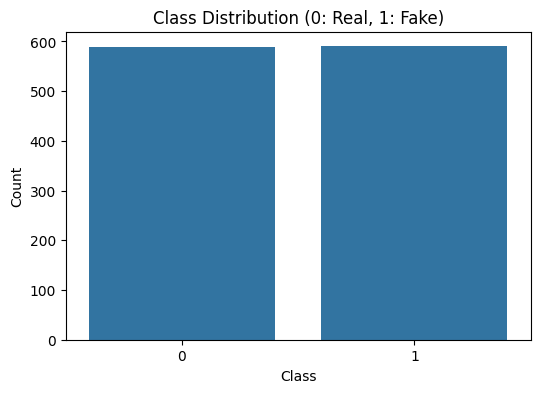

In [3]:
def visualize_class_distribution(labels):
    plt.figure(figsize=(6, 4))
    sns.countplot(x=labels)
    plt.title("Class Distribution (0: Real, 1: Fake)")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.savefig("class_distribution.png")
    plt.show()

# Execute immediately
visualize_class_distribution(labels)

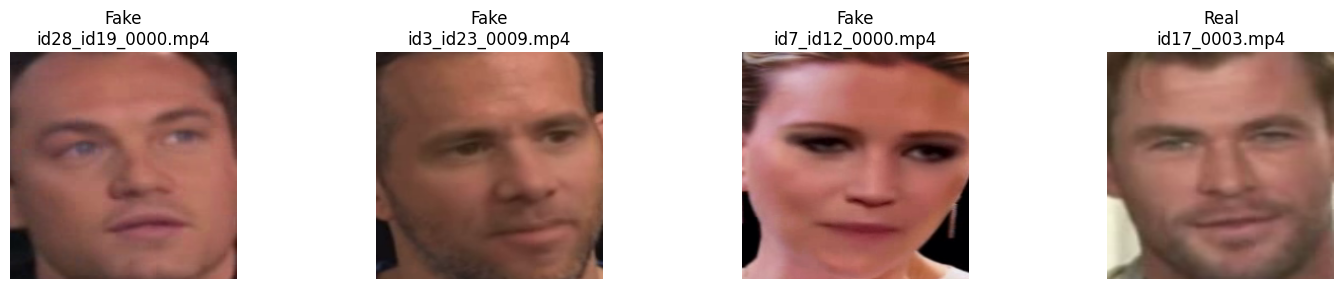

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os

def visualize_sample_frames(video_paths, labels, mtcnn, num_samples=4):
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))  # Single row for frames only
    indices = np.random.choice(len(video_paths), num_samples, replace=False)

    for i, idx in enumerate(indices):
        video_path = video_paths[idx]
        label = "Fake" if labels[idx] == 1 else "Real"
        cap = cv2.VideoCapture(video_path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        cap.set(cv2.CAP_PROP_POS_FRAMES, total_frames // 2)
        ret, frame = cap.read()
        cap.release()

        if ret:
            face = extract_face(frame, mtcnn)
            if face is not None and face.size != 0:
                face_rgb = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
                axes[i].imshow(face_rgb)
                axes[i].set_title(f"{label}\n{os.path.basename(video_path)}")
                axes[i].axis('off')
            else:
                axes[i].text(0.5, 0.5, "No face", ha='center', va='center')
                axes[i].axis('off')
        else:
            axes[i].text(0.5, 0.5, "Invalid frame", ha='center', va='center')
            axes[i].axis('off')

    plt.tight_layout()
    plt.savefig("sample_frames.png")
visualize_sample_frames(video_paths, labels, mtcnn)

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

def visualize_three_frames_flow(video_path, mtcnn, label="Unknown"):
    # Open the video
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

  
    frame_indices = np.linspace(0, total_frames - 1, 5, dtype=int)[:4]  
    frames = []
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            face = extract_face(frame, mtcnn)
            if face is not None and face.size != 0:
                # Resize face to a consistent size for better flow computation
                face = cv2.resize(face, (128, 128)) 
                frames.append(face)
            else:
                frames.append(None)
        else:
            frames.append(None)
    cap.release()

    # Compute optical flow between consecutive frames
    flows = []
    for i in range(len(frames) - 1):
        if frames[i] is not None and frames[i + 1] is not None:
            flow = compute_optical_flow(frames[i], frames[i + 1])
            flows.append(flow)
        else:
            flows.append(None)

    # Create a figure with a 2x3 grid
    fig, axes = plt.subplots(2, 3, figsize=(12, 6))

    # Plot the first 3 frames
    for i in range(3):
        if frames[i] is not None:
            frame_rgb = cv2.cvtColor(frames[i], cv2.COLOR_BGR2RGB)
            axes[0, i].imshow(frame_rgb)
            axes[0, i].set_title(f"Frame {i+1}\n{label}")
            axes[0, i].axis('off')
        else:
            axes[0, i].text(0.5, 0.5, "No face", ha='center', va='center')
            axes[0, i].axis('off')

    # Visualize optical flow magnitude only
    for i in range(3):
        if flows[i] is not None:
            flow = flows[i]
            # Compute magnitude
            mag = np.sqrt(flow[..., 0]**2 + flow[..., 1]**2)

            # Debug: Print detailed flow statistics
            avg_mag = np.mean(mag)
            max_mag = np.max(mag)
            non_zero_flow = np.sum(mag > 0.1) / mag.size * 100  # Percentage of significant flow
            print(f"Flow {i+1}→{i+2}: Average magnitude = {avg_mag:.2f}, Max magnitude = {max_mag:.2f}, "
                  f"Significant flow = {non_zero_flow:.2f}%")

            # Enhanced normalization: Use percentile-based scaling to improve contrast
            mag_threshold = np.percentile(mag, 95)  
            mag_norm = np.clip(mag / (mag_threshold + 1e-6), 0, 1)  
            mag_norm = np.where(mag > 0.1, mag_norm, 0)  

            # Display magnitude as a heatmap
            axes[1, i].imshow(mag_norm, cmap='jet')  
            axes[1, i].set_title(f"Flow {i+1}→{i+2}")
            axes[1, i].axis('off')
        else:
            axes[1, i].text(0.5, 0.5, "No flow", ha='center', va='center')
            axes[1, i].axis('off')

    plt.tight_layout()
    plt.savefig("three_frames_flow.png")

Flow 1→2: Average magnitude = 2.68, Max magnitude = 7.90, Significant flow = 96.46%
Flow 2→3: Average magnitude = 5.77, Max magnitude = 21.71, Significant flow = 97.07%
Flow 3→4: Average magnitude = 2.93, Max magnitude = 12.84, Significant flow = 94.63%


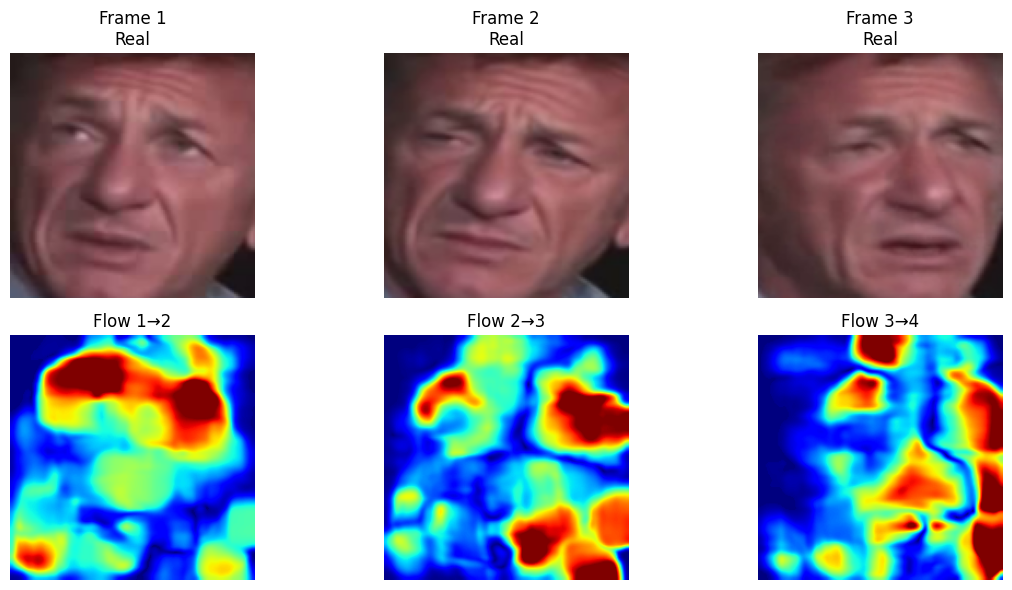

In [ ]:
video_idx = 0  # Choose any index
video_path = video_paths[video_idx]
label = "Fake" if labels[video_idx] == 1 else "Real"
visualize_three_frames_flow(video_path, mtcnn, label)

In [ ]:

def split_dataset(video_paths, labels):
    train_paths, val_paths, train_labels, val_labels = train_test_split(
        video_paths, labels, test_size=0.3, random_state=42, stratify=labels)
    logging.info(f"Train: {len(train_paths)}, Val: {len(val_paths)}")
    return train_paths, val_paths, train_labels, val_labels

train_paths, val_paths, train_labels, val_labels = split_dataset(video_paths, labels)

In [ ]:
from torch.utils.data import DataLoader
from torchvision import transforms

def prepare_data_loaders(train_paths, val_paths, train_labels, val_labels, mtcnn):
    train_transform = transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    val_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    train_dataset = DeepfakeDataset(train_paths, train_labels, transform=train_transform, num_frames=10, mtcnn=mtcnn)
    val_dataset = DeepfakeDataset(val_paths, val_labels, transform=val_transform, num_frames=10, mtcnn=mtcnn)

    train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=0, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=0, pin_memory=True)

    return train_loader, val_loader, train_dataset, val_dataset
train_loader, val_loader, train_dataset, val_dataset = prepare_data_loaders(
    train_paths, val_paths, train_labels, val_labels, mtcnn
)

In [ ]:
import torch
import torch.nn as nn
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torch.nn import TransformerEncoder, TransformerEncoderLayer

class HybridModel(nn.Module):
    def __init__(self, num_frames=10):
        super(HybridModel, self).__init__()
        self.efficientnet = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        for param in self.efficientnet.parameters():
            param.requires_grad = True
        self.efficientnet.classifier = nn.Identity()

        self.feature_dim = 1280
        self.num_frames = num_frames

        # Positional encoding (learnable)
        self.pos_embedding = nn.Parameter(torch.randn(1, num_frames, self.feature_dim))

        encoder_layer = TransformerEncoderLayer(
            d_model=self.feature_dim,
            nhead=8,
            dim_feedforward=2048,
            batch_first=True,
            dropout=0.2
        )
        self.transformer = TransformerEncoder(encoder_layer, num_layers=1)

        # Optical flow branch
        self.flow_conv = nn.Sequential(
            nn.Conv2d(2, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((7, 7))
        )
        self.flow_fc = nn.Linear(64 * 7 * 7, 128)

        # Fusion + classification
        self.fc1 = nn.Linear(self.feature_dim + 128, 256)
        self.fc2 = nn.Linear(256, 1)
        self.dropout = nn.Dropout(0.2)
        self.relu = nn.ReLU()

    def forward(self, frames, flows):
        batch_size, num_frames, c, h, w = frames.size()

        # Frame feature extraction
        frames = frames.view(batch_size * num_frames, c, h, w)
        frame_features = self.efficientnet(frames)
        frame_features = frame_features.view(batch_size, num_frames, -1)

        # Add positional encoding
        frame_features = frame_features + self.pos_embedding[:, :num_frames, :]

        # Temporal modeling
        transformer_out = self.transformer(frame_features)
        temporal_features = transformer_out.max(dim=1)[0]

        # Optical flow feature extraction
        flow_features = []
        for t in range(num_frames):
            flow_map = flows[:, t, :, :, :]  
            conv_out = self.flow_conv(flow_map)
            flow_features.append(conv_out)

        flow_features = torch.stack(flow_features, dim=1)  
        flow_features = flow_features.max(dim=1)[0]        
        flow_features = flow_features.view(batch_size, -1) 
        flow_features = self.relu(self.flow_fc(flow_features))  
        # Combine and classify
        combined = torch.cat([temporal_features, flow_features], dim=1)
        x = self.dropout(self.relu(self.fc1(combined)))
        x = self.fc2(x)

        return x, temporal_features

model = HybridModel(num_frames=10).to(device)

In [ ]:
!pip install torchinfo

In [ ]:
from torchinfo import summary
summary(model)

Layer (type:depth-idx)                                            Param #
HybridModel                                                       3,840
├─EfficientNet: 1-1                                               --
│    └─Sequential: 2-1                                            --
│    │    └─Conv2dNormActivation: 3-1                             928
│    │    └─Sequential: 3-2                                       1,448
│    │    └─Sequential: 3-3                                       16,714
│    │    └─Sequential: 3-4                                       46,640
│    │    └─Sequential: 3-5                                       242,930
│    │    └─Sequential: 3-6                                       543,148
│    │    └─Sequential: 3-7                                       2,026,348
│    │    └─Sequential: 3-8                                       717,232
│    │    └─Conv2dNormActivation: 3-9                             412,160
│    └─AdaptiveAvgPool2d: 2-2                           

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import logging

# Setup logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

def train_model(model, train_loader, val_loader, device, num_epochs=15):
    model = model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, verbose=True)

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    best_val_loss = float('inf')

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        with tqdm(total=len(train_loader), desc=f"Epoch {epoch+1}/{num_epochs}") as pbar:
            for frames, flows, labels in train_loader:
                frames, flows, labels = frames.to(device), flows.to(device), labels.to(device)
                if len(frames.shape) == 4:
                    frames = frames.unsqueeze(0)
                    flows = flows.unsqueeze(0)
                    labels = labels.unsqueeze(0)

                labels = labels.float().view(-1, 1)  

                optimizer.zero_grad()
                outputs, _ = model(frames, flows)  
                loss = criterion(outputs, labels)  

                loss.backward()
                optimizer.step()

                running_loss += loss.item() * frames.size(0)

                preds = (torch.sigmoid(outputs) > 0.5).float()
                correct += (preds == labels).sum().item()
                total += labels.size(0)

                batch_loss = running_loss / total
                batch_acc = correct / total
                pbar.set_postfix({'loss': f'{batch_loss:.4f}', 'acc': f'{batch_acc:.4f}'})
                pbar.update(1)

        epoch_loss = running_loss / total
        epoch_acc = correct / total
        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc)
        logging.info(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {epoch_loss:.4f} - Train Accuracy: {epoch_acc:.4f}")

        # Validation
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for frames, flows, labels in val_loader:
                frames, flows, labels = frames.to(device), flows.to(device), labels.to(device)
                if len(frames.shape) == 4:
                    frames = frames.unsqueeze(0)
                    flows = flows.unsqueeze(0)
                    labels = labels.unsqueeze(0)

                labels = labels.float().view(-1, 1)
                outputs, _ = model(frames, flows)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * frames.size(0)

                preds = (torch.sigmoid(outputs) > 0.5).float()
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

            val_loss /= val_total
            val_acc = val_correct / val_total
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        scheduler.step(val_loss)

        logging.info(f"Validation Loss: {val_loss:.4f} - Validation Accuracy: {val_acc:.4f}")

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "deepfake_transformer_best.pth")
            logging.info("Best model saved.")

    return train_losses, train_accs, val_losses, val_accs


l
model = HybridModel(num_frames=10).to(device)
train_losses, train_accs, val_losses, val_accs = train_model(
    model, train_loader, val_loader, device, num_epochs=15
)


Epoch 15/15: 100%|██████████| 207/207 [05:40<00:00,  1.65s/it, loss=0.1349, acc=0.9479]


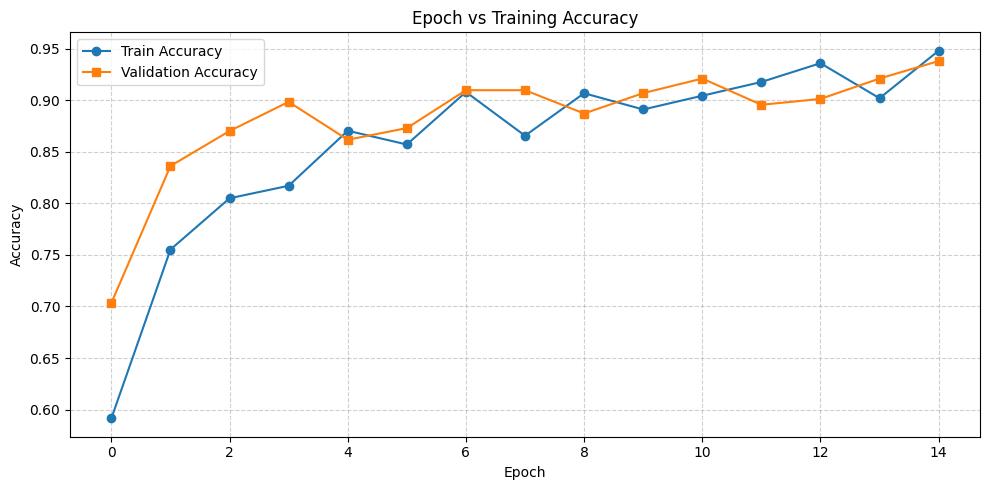

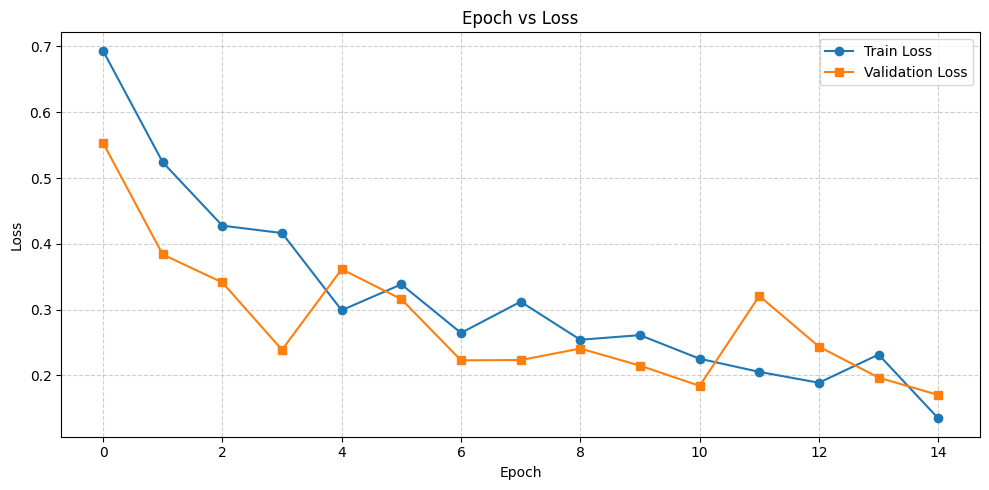

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Number of epochs
epochs = list(range(len(train_accs)))

# Plot Accuracy
plt.figure(figsize=(10, 5))
plt.plot(epochs, train_accs, marker='o', label='Train Accuracy')
plt.plot(epochs, val_accs, marker='s', label='Validation Accuracy')
plt.title('Epoch vs Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xticks(np.arange(0, len(epochs), 2))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Plot Loss
plt.figure(figsize=(10, 5))
plt.plot(epochs, train_losses, marker='o', label='Train Loss')
plt.plot(epochs, val_losses, marker='s', label='Validation Loss')
plt.title('Epoch vs Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(np.arange(0, len(epochs), 2))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()




Validation Metrics:
Loss      : 0.1704
Accuracy  : 0.9379
Precision : 0.9379
Recall    : 0.9379
F1 Score  : 0.9379


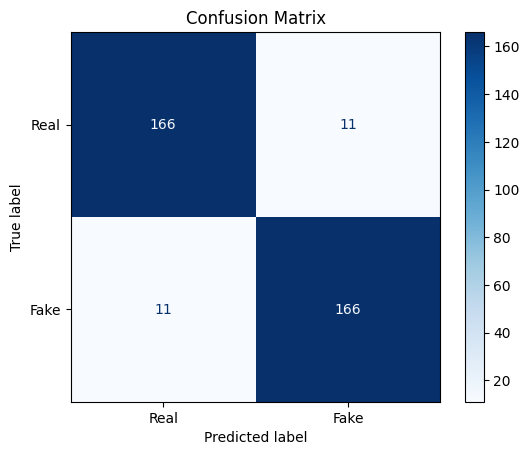

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, accuracy_score
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

def evaluate_model_metrics(model, val_loader, device):
    model.eval()
    model.to(device)
    criterion = nn.BCEWithLogitsLoss()

    all_preds = []
    all_labels = []
    total_loss = 0.0
    total_samples = 0

    with torch.no_grad():
        for frames, flows, labels in val_loader:
            frames, flows, labels = frames.to(device), flows.to(device), labels.to(device)

            # Ensure batch dimension exists
            if len(frames.shape) == 4:
                frames = frames.unsqueeze(0)
                flows = flows.unsqueeze(0)
                labels = labels.unsqueeze(0)

            outputs, _ = model(frames, flows)

            # Flatten both predictions and labels to 1D
            outputs = outputs.view(-1)
            labels = labels.view(-1)

            # Compute loss
            loss = criterion(outputs, labels)
            total_loss += loss.item() * labels.size(0)
            total_samples += labels.size(0)

            # Apply sigmoid and threshold for predictions
            preds = (torch.sigmoid(outputs) > 0.5).float()

            all_preds.extend(preds.cpu().numpy().tolist())
            all_labels.extend(labels.cpu().numpy().tolist())

    # Convert to int for classification metrics
    all_preds = [int(p) for p in all_preds]
    all_labels = [int(l) for l in all_labels]

    # Compute metrics
    val_loss = total_loss / total_samples
    val_accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)

    # Display metrics
    print(f"\nValidation Metrics:")
    print(f"Loss      : {val_loss:.4f}")
    print(f"Accuracy  : {val_accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Real", "Fake"])
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix")
    plt.show()
evaluate_model_metrics(model, val_loader, device)


AUC Score: 0.9845


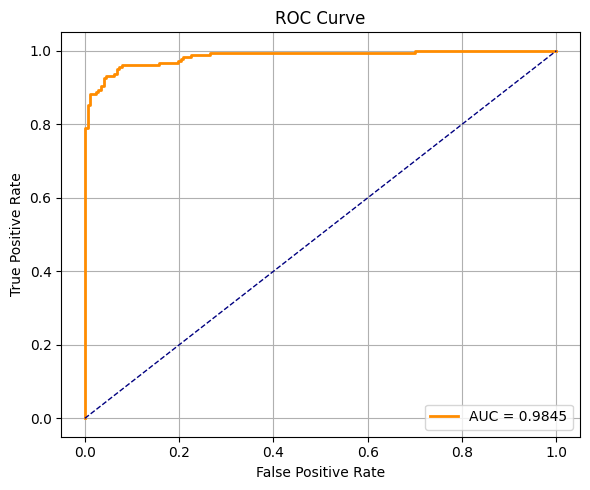

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import torch
import matplotlib.pyplot as plt

def evaluate_auc_and_plot_roc(model, val_loader, device):
    model.eval()
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for frames, flows, labels in val_loader:
            frames, flows, labels = frames.to(device), flows.to(device), labels.to(device)

            # Add batch dimension if needed
            if len(frames.shape) == 4:
                frames = frames.unsqueeze(0)
                flows = flows.unsqueeze(0)
                labels = labels.unsqueeze(0)

            outputs, _ = model(frames, flows)

            # Flatten predictions and labels to 1D
            probs = torch.sigmoid(outputs).view(-1).cpu().numpy()
            labels = labels.view(-1).cpu().numpy()

            all_probs.extend(probs)
            all_labels.extend(labels)

    # Compute AUC
    auc_score = roc_auc_score(all_labels, all_probs)
    print(f"AUC Score: {auc_score:.4f}")

    # ROC Curve
    fpr, tpr, _ = roc_curve(all_labels, all_probs)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"AUC = {auc_score:.4f}")
    plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
evaluate_auc_and_plot_roc(model, val_loader, device)


Pruned model saved to deepfake_transformer_pruned.pth
Prediction: Fake, Confidence: 99.81%, Fake Probability : 0.9981


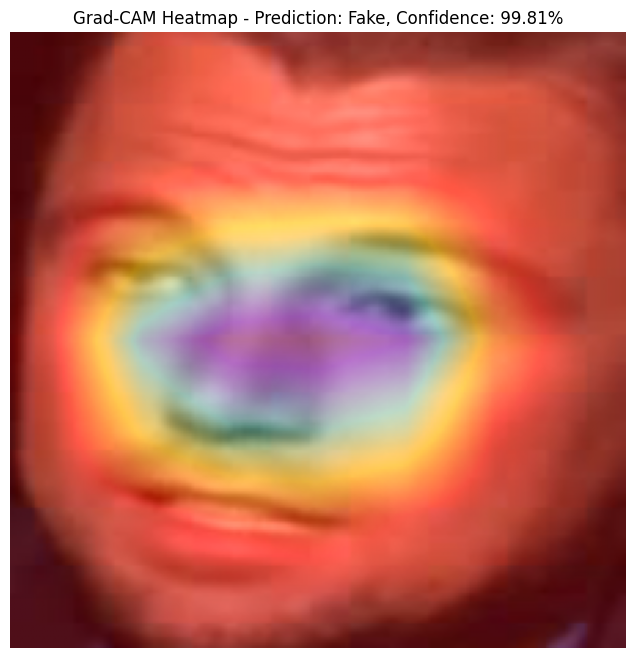

In [ ]:
import torch
import torch.nn as nn
import cv2
import numpy as np
from torchcam.methods import GradCAM
import torch.nn.utils.prune as prune
import logging
import matplotlib.pyplot as plt
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from facenet_pytorch import MTCNN
from PIL import Image
import torchvision.transforms as transforms
from torch.nn import TransformerEncoder, TransformerEncoderLayer  # Added missing import

logging.basicConfig(level=logging.INFO)

# Define transforms (same as test code)
val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Define the HybridModel
class HybridModel(nn.Module):
    def __init__(self, num_frames=3):
        super(HybridModel, self).__init__()
        self.efficientnet = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        for param in self.efficientnet.parameters():
            param.requires_grad = True
        self.efficientnet.classifier = nn.Identity()

        self.feature_dim = 1280
        self.num_frames = num_frames

        # Positional encoding (learnable)
        self.pos_embedding = nn.Parameter(torch.randn(1, num_frames, self.feature_dim))

        encoder_layer = TransformerEncoderLayer(
            d_model=self.feature_dim,
            nhead=8,
            dim_feedforward=2048,
            batch_first=True,
            dropout=0.2
        )
        self.transformer = TransformerEncoder(encoder_layer, num_layers=1)

        # Optical flow branch
        self.flow_conv = nn.Sequential(
            nn.Conv2d(2, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((7, 7))
        )
        self.flow_fc = nn.Linear(64 * 7 * 7, 128)

        # Fusion + classification
        self.fc1 = nn.Linear(self.feature_dim + 128, 256)
        self.fc2 = nn.Linear(256, 1)
        self.dropout = nn.Dropout(0.2)
        self.relu = nn.ReLU()

    def forward(self, frames, flows):
        batch_size, num_frames, c, h, w = frames.size()

        # Frame feature extraction
        frames = frames.view(batch_size * num_frames, c, h, w)
        frame_features = self.efficientnet(frames)
        frame_features = frame_features.view(batch_size, num_frames, -1)

        frame_features = frame_features + self.pos_embedding[:, :num_frames, :]

        # Temporal modeling
        transformer_out = self.transformer(frame_features)
        temporal_features = transformer_out.max(dim=1)[0]

        # Optical flow feature extraction
        flow_features = []
        for t in range(num_frames):
            flow_map = flows[:, t, :, :, :]  
            conv_out = self.flow_conv(flow_map)
            flow_features.append(conv_out)

        flow_features = torch.stack(flow_features, dim=1)  
        flow_features = flow_features.max(dim=1)[0]        
        flow_features = flow_features.view(batch_size, -1) 
        flow_features = self.relu(self.flow_fc(flow_features))  

        # Combine and classify
        combined = torch.cat([temporal_features, flow_features], dim=1)
        x = self.dropout(self.relu(self.fc1(combined)))
        x = self.fc2(x)

        return x, temporal_features

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = HybridModel(num_frames=3).to(device)
model.load_state_dict(torch.load(r"/content/drive/MyDrive/deepfake_transformer_best.pth", map_location=device))
model.eval()

# Grad-CAM Setup
class GradCAMModel(nn.Module):
    def __init__(self, model):
        super(GradCAMModel, self).__init__()
        self.model = model
        self.target_layer = model.efficientnet.features[-1]  

    def forward(self, frames, flows):
        batch_size, num_frames, c, h, w = frames.size()
        frames = frames.view(batch_size * num_frames, c, h, w)
        x = self.model.efficientnet.features(frames)
        x = x.view(batch_size, num_frames, -1)
        x = self.model.transformer(x)
        temporal_features = x.max(dim=1)[0]
        flow_features = []
        for t in range(num_frames):
            flow_map = flows[:, t, :, :, :]
            conv_out = self.model.flow_conv(flow_map)
            flow_features.append(conv_out)
        flow_features = torch.stack(flow_features, dim=1).max(dim=1)[0].view(batch_size, -1)
        flow_features = self.model.relu(self.model.flow_fc(flow_features))
        combined = torch.cat([temporal_features, flow_features], dim=1)
        x = self.model.dropout(self.model.relu(self.model.fc1(combined)))
        x = self.model.fc2(x)
        return x

cam_model = GradCAMModel(model)
cam = GradCAM(cam_model, target_layer=cam_model.target_layer)

def extract_face(frame, mtcnn):
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    boxes, _ = mtcnn.detect(frame_rgb)
    if boxes is not None and len(boxes) > 0:
        box = boxes[0]
        x1, y1, x2, y2 = map(int, box)
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(frame.shape[1], x2), min(frame.shape[0], y2)
        face = frame[y1:y2, x1:x2]
        if face.size == 0:
            return np.zeros((224, 224, 3), dtype=np.uint8)
        return cv2.resize(face, (224, 224))
    return np.zeros((224, 224, 3), dtype=np.uint8)

def compute_optical_flow(prev_frame, curr_frame):
    prev_gray = cv2.cvtColor(prev_frame, cv2.COLOR_BGR2GRAY)
    curr_gray = cv2.cvtColor(curr_frame, cv2.COLOR_BGR2GRAY)
    flow = cv2.calcOpticalFlowFarneback(prev_gray, curr_gray, None, 0.5, 3, 15, 3, 5, 1.2, 0)
    flow = cv2.GaussianBlur(flow, (5, 5), 0)
    return cv2.resize(flow, (224, 224))

def preprocess_video(video_path, num_frames=3, mtcnn=None):
    cap = cv2.VideoCapture(video_path)
    frames = []
    flows = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    logging.info(f"Total frames: {total_frames}, Selected indices: {np.linspace(0, total_frames - 1, num_frames + 1, dtype=int)[:num_frames]}")
    frame_indices = np.linspace(0, total_frames - 1, num_frames + 1, dtype=int)[:num_frames]
    prev_frame = None
    for i in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, i)
        ret, frame = cap.read()
        if not ret:
            logging.warning(f"Failed to read frame at index {i} in {video_path}")
            frame = np.zeros((224, 224, 3), dtype=np.uint8)
        face = extract_face(frame, mtcnn) if mtcnn else frame
        frames.append(face)
        if prev_frame is not None:
            flow = compute_optical_flow(prev_frame, face)
            flows.append(flow)
        else:
            flows.append(np.zeros((224, 224, 2), dtype=np.float32))
        prev_frame = face
    cap.release()
    if len(frames) < num_frames:
        frames.extend([np.zeros((224, 224, 3), dtype=np.uint8)] * (num_frames - len(frames)))
        flows.extend([np.zeros((224, 224, 2), dtype=np.float32)] * (num_frames - len(flows)))
    frames = np.stack(frames)
    flows = np.stack(flows)
    frames = torch.stack([val_test_transform(Image.fromarray(f)) for f in frames])
    flows = torch.tensor(flows, dtype=torch.float32).permute(0, 3, 1, 2)
    logging.info(f"Preprocessed frames shape for {video_path}: {frames.shape}, flows shape: {flows.shape}")
    return frames.unsqueeze(0), flows.unsqueeze(0)  # Add batch dimension

def generate_gradcam(model, video_path, device, mtcnn=None):
    model.eval()
    frames, flows = preprocess_video(video_path, num_frames=3, mtcnn=mtcnn)
    logging.info(f"Frames tensor shape: {frames.shape}, Flows tensor shape: {flows.shape}")
    frames, flows = frames.to(device), flows.to(device)

    model.zero_grad()
    output, _ = model(frames, flows)  
    logging.info(f"Raw probability of being fake: {torch.sigmoid(output).item()}")
    output.backward(retain_graph=True)  
    cam_map = cam(scores=output, class_idx=0)
    cam_map = cam_map[0]  
    cam_map = cam_map.to(device)  
    cam_map = cam_map.cpu().detach().numpy()
    if cam_map.ndim > 2:
        cam_map = np.mean(cam_map, axis=0)  
    if cam_map.ndim != 2:
        raise ValueError(f"Expected 2D array for cam_map, got shape {cam_map.shape}")
    cam_map = np.interp(cam_map, (cam_map.min(), cam_map.max()), (0, 255)).astype(np.uint8)
    cam_map = cv2.resize(cam_map, (224, 224))
    heatmap = cv2.applyColorMap(cam_map, cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255

    # Reverse normalization on the GPU and then move to CPU for OpenCV
    mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=device).view(3, 1, 1)
    frame_tensor = frames[0, 0] * std + mean  
    frame = cv2.cvtColor((frame_tensor.cpu().permute(1, 2, 0).numpy() * 255).astype(np.uint8), cv2.COLOR_RGB2BGR)

    superimposed_img = heatmap * 0.4 + frame / 255.0
    superimposed_img = np.clip(superimposed_img, 0, 1)
    logging.info(f"superimposed_img shape: {superimposed_img.shape}, dtype: {superimposed_img.dtype}, min: {superimposed_img.min()}, max: {superimposed_img.max()}")
    if np.any(np.isnan(superimposed_img)) or np.any(np.isinf(superimposed_img)):
        logging.error("superimposed_img contains NaN or infinite values")
        superimposed_img = np.clip(superimposed_img, 0, 1, out=superimposed_img)

    return superimposed_img, output

# Pruning
for name, module in model.named_modules():
    if isinstance(module, (torch.nn.Conv2d, torch.nn.Linear)):
        prune.l1_unstructured(module, name='weight', amount=0.2)
        prune.remove(module, 'weight')

torch.save(model.state_dict(), "deepfake_transformer_pruned.pth")
print("Pruned model saved to deepfake_transformer_pruned.pth")

# Test with Grad-CAM
mtcnn = MTCNN(image_size=224, margin=20, keep_all=False, min_face_size=50, device=device)
fake_video_path = r"/content/drive/MyDrive/celeb/train/Celeb-synthesis/id19_id27_0004.mp4"

superimposed_img, output = generate_gradcam(model, fake_video_path, device, mtcnn)
prob_fake = torch.sigmoid(output).item()
prediction = "Fake" if prob_fake > 0.1 else "Real"
confidence = 100 * (1 - prob_fake) if prob_fake <= 0.5 else 100 * prob_fake

print(f"Prediction: {prediction}, Confidence: {confidence:.2f}%, Fake Probability : {prob_fake:.4f}")
# Display Grad-CAM visualization
plt.figure(figsize=(8, 8))
plt.imshow(superimposed_img)
plt.title(f"Grad-CAM Heatmap - Prediction: {prediction}, Confidence: {confidence:.2f}%")
plt.axis('off')
plt.show()

In [9]:
# Pruning
for name, module in model.named_modules():
    if isinstance(module, (torch.nn.Conv2d, torch.nn.Linear)):
        prune.l1_unstructured(module, name='weight', amount=0.2)
        prune.remove(module, 'weight')

torch.save(model.state_dict(), "deepfake_transformer_pruned.pth")
print("Pruned model saved to deepfake_transformer_pruned.pth")

Pruned model saved to deepfake_transformer_pruned.pth


In [ ]:
import torch
import torch.onnx
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torch.nn import TransformerEncoder, TransformerEncoderLayer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class HybridModel(torch.nn.Module):
    def __init__(self, num_frames=3):
        super(HybridModel, self).__init__()
        self.efficientnet = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        for param in self.efficientnet.parameters():
            param.requires_grad = True
        self.efficientnet.classifier = torch.nn.Identity()

        self.feature_dim = 1280
        self.num_frames = num_frames

        # Positional encoding (learnable)
        self.pos_embedding = torch.nn.Parameter(torch.randn(1, num_frames, self.feature_dim))

        encoder_layer = TransformerEncoderLayer(
            d_model=self.feature_dim,
            nhead=8,
            dim_feedforward=2048,
            batch_first=True,
            dropout=0.2
        )
        self.transformer = TransformerEncoder(encoder_layer, num_layers=1)

        # Optical flow branch
        self.flow_conv = torch.nn.Sequential(
            torch.nn.Conv2d(2, 16, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.Conv2d(16, 32, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.Conv2d(32, 64, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.AdaptiveAvgPool2d((7, 7))
        )
        self.flow_fc = torch.nn.Linear(64 * 7 * 7, 128)

        # Fusion + classification
        self.fc1 = torch.nn.Linear(self.feature_dim + 128, 256)
        self.fc2 = torch.nn.Linear(256, 1)
        self.dropout = torch.nn.Dropout(0.2)
        self.relu = torch.nn.ReLU()

    def forward(self, frames, flows):
        batch_size, num_frames, c, h, w = frames.size()

        # Frame feature extraction
        frames = frames.view(batch_size * num_frames, c, h, w)
        frame_features = self.efficientnet(frames)
        frame_features = frame_features.view(batch_size, num_frames, -1)

        # Add positional encoding
        frame_features = frame_features + self.pos_embedding[:, :num_frames, :]

        # Temporal modeling
        transformer_out = self.transformer(frame_features)
        temporal_features = transformer_out.max(dim=1)[0]

        # Optical flow feature extraction
        flow_features = []
        for t in range(num_frames):
            flow_map = flows[:, t, :, :, :]  
            conv_out = self.flow_conv(flow_map)
            flow_features.append(conv_out)

        flow_features = torch.stack(flow_features, dim=1)  
        flow_features = flow_features.max(dim=1)[0]        
        flow_features = flow_features.view(batch_size, -1) 
        flow_features = self.relu(self.flow_fc(flow_features))  

        # Combine and classify
        combined = torch.cat([temporal_features, flow_features], dim=1)
        x = self.dropout(self.relu(self.fc1(combined)))
        x = self.fc2(x)

        return x, temporal_features

# Load the trained and pruned model
model = HybridModel(num_frames=3).to(device)
model.load_state_dict(torch.load("/content/deepfake_transformer_pruned.pth"))  
model.eval()  


batch_size = 1
num_frames = 3
channels = 3
height = 224
width = 224
flow_channels = 2

# Create dummy input tensors
sample_frames = torch.randn(batch_size, num_frames, channels, height, width).to(device)
sample_flows = torch.randn(batch_size, num_frames, flow_channels, height, width).to(device)

# Export the model to ONNX with updated opset version
torch.onnx.export(
    model,                     
    (sample_frames, sample_flows),  
    "hybrid_model.onnx",       
    export_params=True,        
    opset_version=14,          
    do_constant_folding=True,  
    input_names=['frames', 'flows'],  
    output_names=['output', 'temporal_features'],  
    dynamic_axes={'frames': {0: 'batch_size'}, 'flows': {0: 'batch_size'}}  

print("Model has been converted to ONNX and saved as 'hybrid_model.onnx'")

Model has been converted to ONNX and saved as 'hybrid_model.onnx'


In [28]:
pip install onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 70.0 MB/s eta 0:00:00
